In [17]:
from bo import bo_full_loop, acq_type_mapping, calculate_cumulative_regret, prepare_objective_func
from lmabo import lm_assisted_adaptive_bo
from constants import DIMS, EXP_RUNS, NUMERICAL_RESULTS_DIR, FIG_DIR, OBJECTIVE_FUNCTIONS

import argparse
from botorch.test_functions import *
import matplotlib.pyplot as plt
import numpy as np
import os
import time
import torch
from torch.quasirandom import SobolEngine

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.double  # Use double precision for GP models

matplotlib_colors = [
    '#1f77b4',  # Muted blue (from default 'tab10' palette)
    '#ff7f0e',  # Orange
    '#2ca02c',  # Green
    '#d62728',  # Red
    '#9467bd',  # Purple
    '#8c564b',  # Brown
    '#e377c2',  # Pink
    '#7f7f7f',  # Gray
    '#bcbd22',  # Olive/Lime Green
    '#17becf',  # Cyan/Teal
    '#a6cee3',  # Light Blue (from 'Paired' palette)
    '#b2df8a',  # Light Green
    '#fb9a99',  # Light Red
    '#fdbf6f',  # Light Orange
    '#cab2d6'   # Light Purple
]

def plot_results(problem_name):
    legends = list(acq_type_mapping.keys())
    legends.append("lmabo")
    plt.figure(figsize=(16, 10))
    for i, acq_type in enumerate(legends):
        acq_type_values = []
        for exp_idx in range(EXP_RUNS):
            try:
                file_name = f"{NUMERICAL_RESULTS_DIR}/{problem_name}/{acq_type}/{exp_idx}.npy"
                best_values = np.load(file_name)
                acq_type_values.append(best_values)
            except:
                print(file_name + " does not exist")
        if len(acq_type_values) > 0:
            acq_type_values = np.stack(acq_type_values)
            mean_acq_type_values = acq_type_values.mean(axis=0)
            std_acq_type_values = acq_type_values.std(axis=0)
            n_iter = np.arange(1, mean_acq_type_values.shape[0]+1)
            plt.plot(
                n_iter, 
                mean_acq_type_values, 
                color=matplotlib_colors[i],
                label=acq_type
            )
            plt.fill_between(
                n_iter, 
                mean_acq_type_values - 0.5*std_acq_type_values, 
                mean_acq_type_values + 0.5*std_acq_type_values, 
                color=matplotlib_colors[i],
                alpha=0.2
            )
    plt.xlabel("Iteration")
    plt.ylabel("Best Function Value Found")
    plt.title(f"BO on {problem_name}")
    plt.legend()
    plt.grid(True)
    os.makedirs(f"{FIG_DIR}", exist_ok=True)
    plt.savefig(f"{FIG_DIR}/{problem_name}.pdf", dpi=300)  # Save plot as PDF

def check_result_complete(folder_path):
    if not os.path.exists(folder_path):
        count = 0
    else:
        count = len([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])
    if count < EXP_RUNS:
        return False
    else:
        return True

def run_problem_lmabo(problem):
    # prepare function
    for item in OBJECTIVE_FUNCTIONS:
        if item.__name__ == problem:
            f = item
            break
    dim = 0
    if hasattr(f, "dim"):
        dim = f.dim
        objective_func = f().to(dtype=dtype, device=device)
    elif f.__name__ == 'Hartmann': 
        dim = 6
        objective_func = f().to(dtype=dtype, device=device)
    else:
        dim = DIMS[f]
        objective_func = f(dim=dim).to(dtype=dtype, device=device)
    
    bounds = torch.tensor(objective_func.bounds, dtype=dtype, device=device)  # Search space bounds
    # Experiment settings
    print(device, bounds.device)
    
    num_initial_points = 2*dim + 1
    num_iterations = 50 if dim <= 10 else 100
    for exp_idx in range(EXP_RUNS):
        print(f"RUN {exp_idx}")
        # Generate initial training data
        sobol = SobolEngine(dimension=dim, scramble=True, seed=exp_idx)
        fixed_train_X  = bounds[0] + (bounds[1] - bounds[0]) * sobol.draw(num_initial_points).to(dtype=dtype, device=device)
        fixed_train_Y  = objective_func(fixed_train_X).unsqueeze(-1) # Evaluate function and reshape
        # run LMABO
        print("Run LMABO")
        folder_path = f"{NUMERICAL_RESULTS_DIR}/{problem}/lmabo"
        if os.path.exists(f"{folder_path}/{exp_idx}.npy"):
            continue
        best_values, acq_type_list = lm_assisted_adaptive_bo(objective_func, fixed_train_X, fixed_train_Y, bounds, num_iterations)
        os.makedirs(folder_path, exist_ok=True)
        np.save(f"{folder_path}/{exp_idx}.npy", best_values)
        # save acq_type_list as text in one line for analysis
        with open(f"{folder_path}/{exp_idx}_acq_types.txt", "w") as f:
            f.write(" ".join(acq_type_list))
            
def run_problem_bo(problem, acq_type):
    # prepare function
    objective_func, dim, bounds = prepare_objective_func(problem)
    # Experiment settings
    print(device, bounds.device)
    
    num_initial_points = 2*dim + 1
    num_iterations = 50 if dim <= 10 else 100
    for exp_idx in range(EXP_RUNS):
        print(f"RUN {exp_idx}")
        # Generate initial training data
        sobol = SobolEngine(dimension=dim, scramble=True, seed=exp_idx)
        fixed_train_X  = bounds[0] + (bounds[1] - bounds[0]) * sobol.draw(num_initial_points).to(dtype=dtype, device=device)
        fixed_train_Y  = objective_func(fixed_train_X).unsqueeze(-1) # Evaluate function and reshape
        # run fixed acq_type
        print(f"Running ({acq_type})")
        folder_path = f"{NUMERICAL_RESULTS_DIR}/{problem}/{acq_type}"
        if os.path.exists(f"{folder_path}/{exp_idx}.npy"):
            print("Completed!")
            continue
        best_values = bo_full_loop(
            objective_func, 
            acq_type, 
            fixed_train_X, fixed_train_Y, 
            bounds,
            num_iterations
        )
        os.makedirs(folder_path, exist_ok=True)
        np.save(f"{folder_path}/{exp_idx}.npy", best_values)    
        
def get_problem_cum_reg(problem, acq_type):
    objective_func, dim, bounds = prepare_objective_func(problem)
    true_minimum = objective_func._optimal_value
    total_cum_reg = 0
    # Load all runs for this acquisition type
    for exp_idx in range(EXP_RUNS):
        file_name = f"{NUMERICAL_RESULTS_DIR}/{problem}/{acq_type}/{exp_idx}.npy"
        best_values = np.load(file_name)
        cum_regret = calculate_cumulative_regret(best_values, true_minimum)[-1]
        print(f"Run {exp_idx}: {cum_regret}")
        total_cum_reg += cum_regret
    print(total_cum_reg/EXP_RUNS)
        
def get_rank_dict(dictionary, reverse=True):
    """
    Create a dictionary mapping items to their rank positions based on values.
    
    Args:
        dictionary: Input dictionary to rank
        reverse: If True, highest value gets rank 1 (default). If False, lowest value gets rank 1.
    
    Returns:
        dict: A dictionary where keys are the original keys and values are their ranks
    """
    # Sort items by value and enumerate to get positions
    sorted_items = sorted(dictionary.items(), key=lambda x: x[1], reverse=reverse)
    # Create a new dictionary with original keys and their rank positions (1-based)
    return {key: rank + 1 for rank, (key, _) in enumerate(sorted_items)}

def get_ranking(problem):
    objective_func, dim, bounds = prepare_objective_func(problem)
    true_minimum = objective_func._optimal_value
    legends = list(acq_type_mapping.keys())
    legends.append("lmabo")
    cum_reg_acq_type = {}
    for i, acq_type in enumerate(legends):
        acq_type_values = []
        for exp_idx in range(EXP_RUNS):
            try:
                file_name = f"{NUMERICAL_RESULTS_DIR}/{problem}/{acq_type}/{exp_idx}.npy"
                best_values = np.load(file_name)
                acq_type_values.append(best_values)
            except:
                pass
        if len(acq_type_values) > 0:
            all_cum_reg = []
            for row in acq_type_values:
                cum_reg = calculate_cumulative_regret(row, true_minimum)[-1]
                all_cum_reg.append(cum_reg)
            cum_reg_acq_type[acq_type] = np.mean(all_cum_reg)
        else:
            cum_reg_acq_type[acq_type] = 1e50
    return get_rank_dict(cum_reg_acq_type, False)

def print_sorted_dict(dictionary, reverse=True, indent=2):
    """
    Pretty print a dictionary sorted by values.
    
    Args:
        dictionary: Input dictionary to sort and print
        reverse: If True, sort in descending order (default). If False, ascending order
        indent: Number of spaces for indentation (default=2)
    """
    # Sort the dictionary by values
    sorted_items = sorted(dictionary.items(), key=lambda x: x[1], reverse=reverse)
    
    # Get the maximum length of keys for alignment
    max_key_length = max(len(str(key)) for key in dictionary.keys())
    
    print("{")
    for key, value in sorted_items:
        # Format each line with proper indentation and alignment
        print(f"{' ' * indent}{str(key):<{max_key_length}} : {value}")
    print("}")
        
def report_ranking(problem_list):
    problem_ranking = {}
    for problem in problem_list:
        problem_ranking[problem] = get_ranking(problem)
    legends = list(acq_type_mapping.keys())
    legends.append("lmabo")
    acq_type_ranking = {}
    for i, acq_type in enumerate(legends):
        acq_type_ranking[acq_type] = 0
        for problem in problem_list:
            rank = problem_ranking[problem][acq_type]
            acq_type_ranking[acq_type] = rank + acq_type_ranking[acq_type]
    print(acq_type_ranking)
    print_sorted_dict(acq_type_ranking)
    
def report_completion():
    """
    Print a table showing number of completed runs for each problem and acquisition type.
    """
    problems = [item.__name__ for item in OBJECTIVE_FUNCTIONS]
    # Add LMABO to acquisition types for complete view
    all_acq_types = list(acq_type_mapping.keys()) + ["lmabo"]
    completed_problems = []
    
    # Calculate padding for pretty printing
    problem_width = max(len(str(p)) for p in problems)
    acq_width = max(len(str(a)) for a in all_acq_types)
    
    # Print header
    header = f"{'Problem':<{problem_width}}|"
    header += "".join(f"{acq:^{acq_width}}|" for acq in all_acq_types)
    print("-" * len(header))
    print(header)
    print("-" * len(header))
    
    # Print each problem's row and check completion
    for problem in problems:
        row = f"{problem:<{problem_width}}|"
        problem_complete = True
        
        for acq in all_acq_types:
            folder_path = f"{NUMERICAL_RESULTS_DIR}/{problem}/{acq}"
            if not os.path.exists(folder_path):
                count = 0
            else:
                count = len([f for f in os.listdir(folder_path) 
                           if f.endswith('.npy') and not f.endswith('_acq_types.npy')])
            row += f"{count:^{acq_width}}|"
            
            # Check if this acquisition type has all runs
            if count < EXP_RUNS:
                problem_complete = False
                
        print(row)
        if problem_complete:
            completed_problems.append(problem)
            
    print("-" * len(header))
    print("Completed: ", completed_problems)
    return completed_problems
            
def report_relative_cumreg(problem):
    """
    Analyze relative performance of acquisition functions for a given problem.
    Returns a sorted dictionary of relative cumulative regrets compared to the best performer.
    
    Args:
        problem_name: Name of the test problem
        true_minimum: True minimum value of the objective function
    """
    objective_func, dim, bounds = prepare_objective_func(problem)
    true_minimum = objective_func._optimal_value
    # Dictionary to store mean cumulative regret for each acquisition type
    mean_cum_regrets = {}
    
    # Process results for each acquisition type
    for acq_type in list(acq_type_mapping.keys()) + ["lmabo"]:
        acq_type_values = []
        
        # Load all runs for this acquisition type
        for exp_idx in range(EXP_RUNS):
            try:
                file_name = f"{NUMERICAL_RESULTS_DIR}/{problem}/{acq_type}/{exp_idx}.npy"
                best_values = np.load(file_name)
                cum_regret = calculate_cumulative_regret(best_values, true_minimum)
                acq_type_values.append(cum_regret)
            except:
                continue
                
        if len(acq_type_values) > 0:
            # Calculate mean cumulative regret across all runs
            mean_cum_regrets[acq_type] = np.mean(np.stack(acq_type_values), axis=0)[-1]
    
    # Find the best performing method (lowest cumulative regret)
    best_method = min(mean_cum_regrets.items(), key=lambda x: x[1])
    best_method_name = best_method[0]
    best_method_regret = best_method[1]
    
    # Calculate relative performance
    relative_performance = {
        acq_type: regret / best_method_regret 
        for acq_type, regret in mean_cum_regrets.items()
    }
    
    # Sort by performance (ascending)
    sorted_performance = dict(sorted(relative_performance.items(), key=lambda x: x[1]))
    
    # Print results in a nice format
    print(f"\nPerformance Analysis for {problem}")
    print(f"Best method: {best_method_name} (baseline)")
    print("\nRelative Cumulative Regret (compared to best):")
    print("-" * 50)
    print(f"{'Method':<15} | {'Relative Regret':>15} | {'vs. Best':>10}")
    print("-" * 50)
    for method, rel_regret in sorted_performance.items():
        print(f"{method:<15} | {rel_regret:>15.3f} | {'+':>2}{(rel_regret-1)*100:>7.1f}%")
    
    return sorted_performance

In [62]:
completed_problems = report_completion()
report_ranking(completed_problems)

-----------------------------------------------------------------------------------------------------------------------
Problem       |  PI   | LogPI |  EI   | LogEI |  UCB  |PosMean|PosSTD |  TS   |  qKG  | qPES  | qMES  | qJES  | lmabo |
-----------------------------------------------------------------------------------------------------------------------
Ackley        |   7   |   7   |   7   |   7   |   7   |   7   |   7   |   7   |   7   |   6   |   6   |   5   |  10   |
Beale         |  10   |  10   |  10   |  10   |  10   |  10   |  10   |  10   |  10   |  10   |  10   |  10   |   0   |
Branin        |  10   |  10   |  10   |  10   |  10   |  10   |  10   |  10   |  10   |  10   |  10   |  10   |  10   |
Bukin         |  10   |  10   |  10   |  10   |  10   |  10   |  10   |  10   |  10   |  10   |  10   |  10   |   0   |
Cosine8       |  10   |  10   |  10   |  10   |  10   |  10   |  10   |  10   |  10   |  10   |  10   |  10   |   0   |
DixonPrice    |  10   |  10   |  10   | 

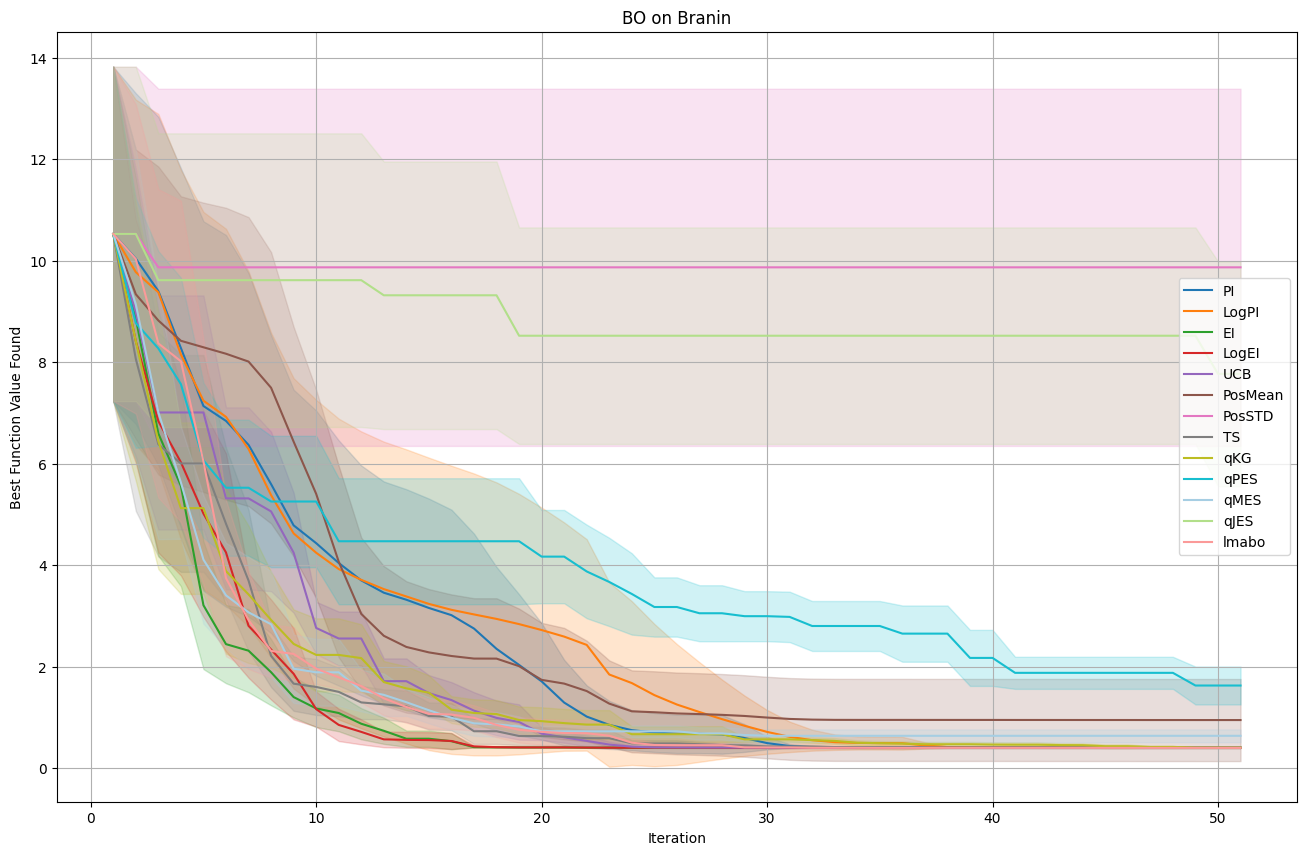

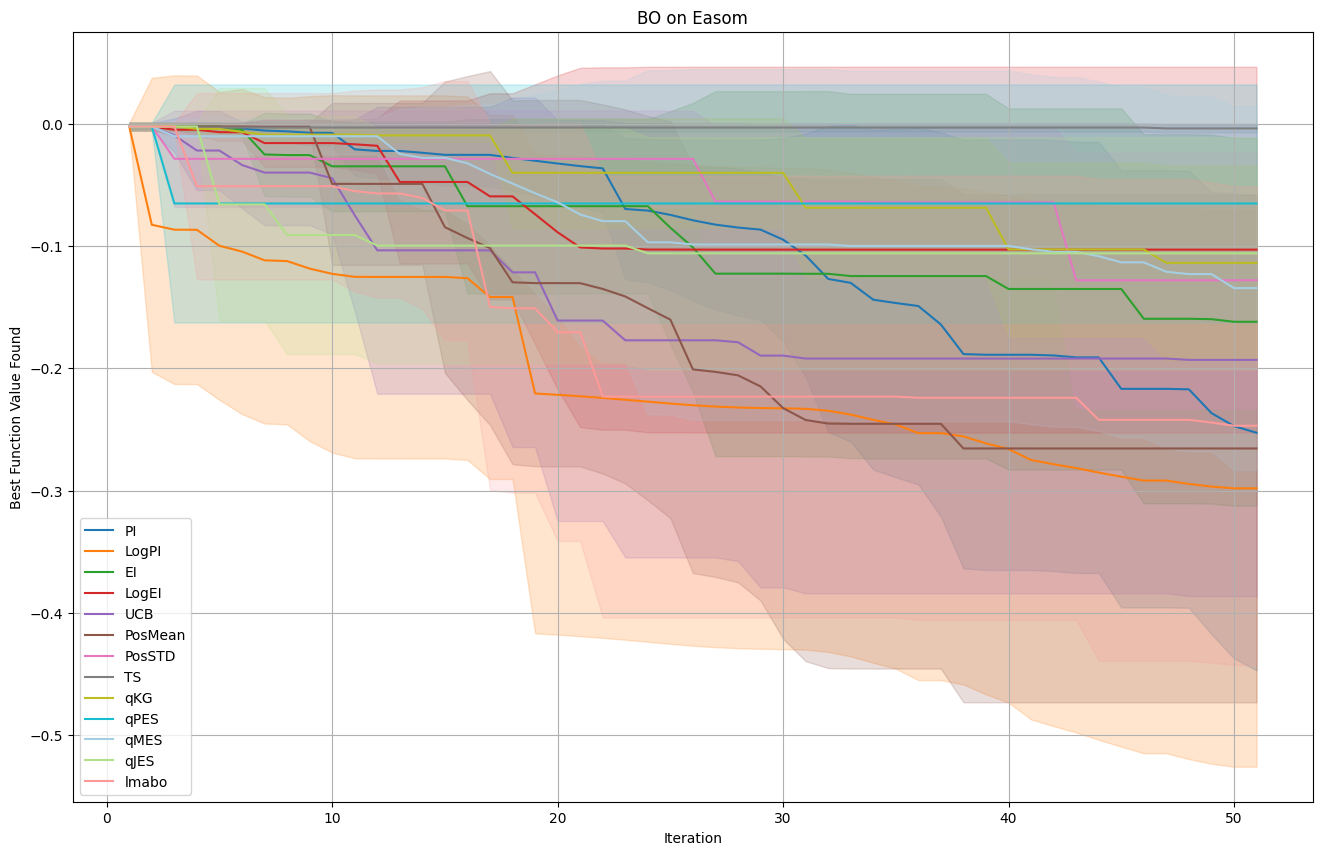

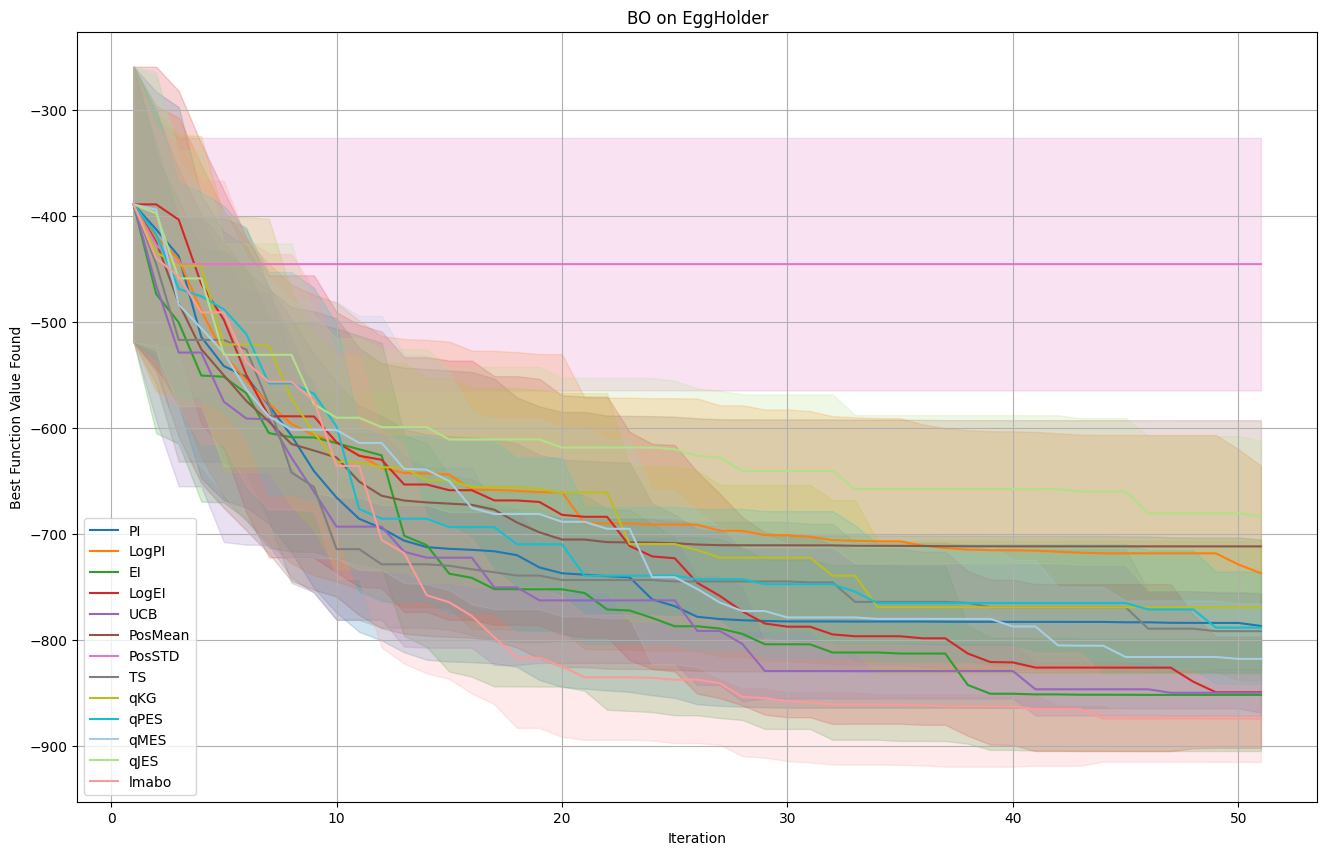

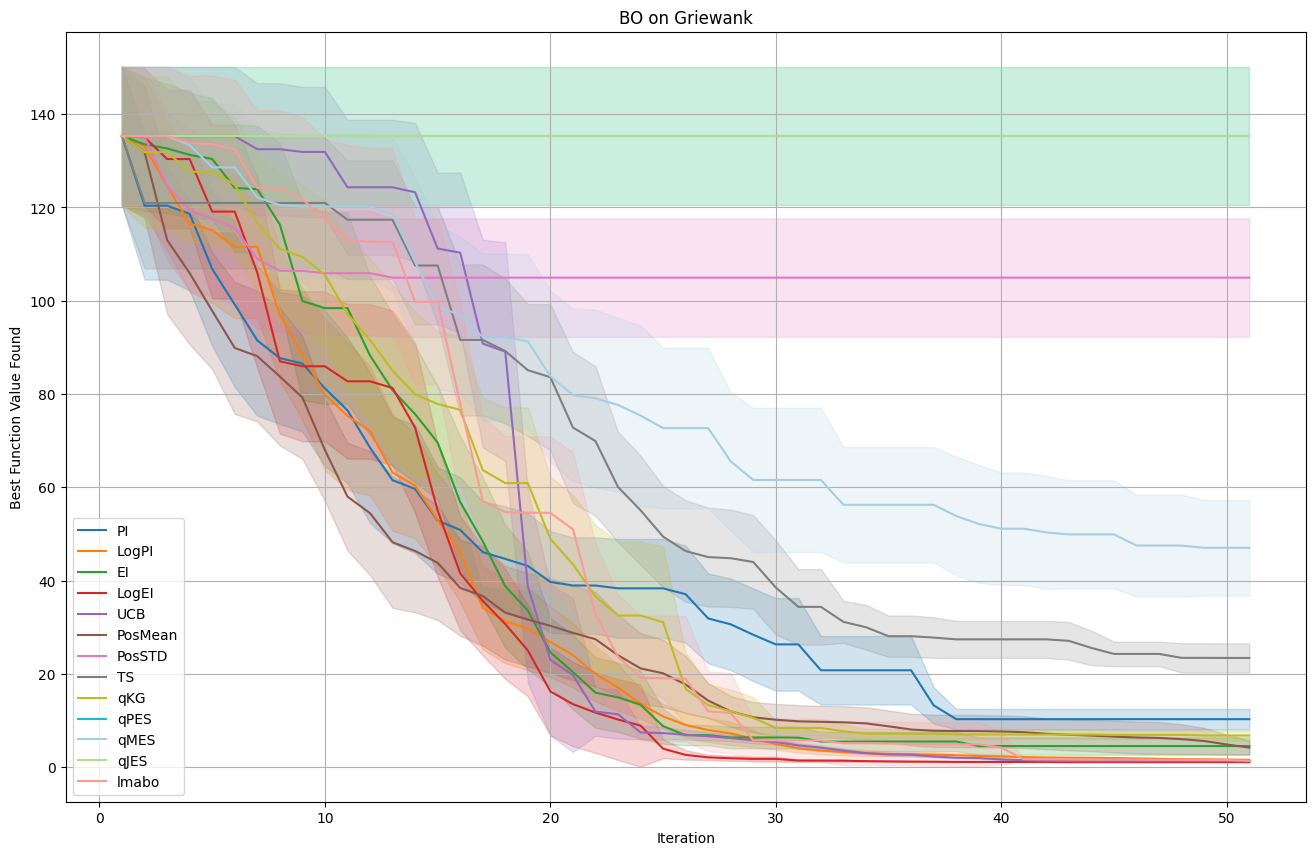

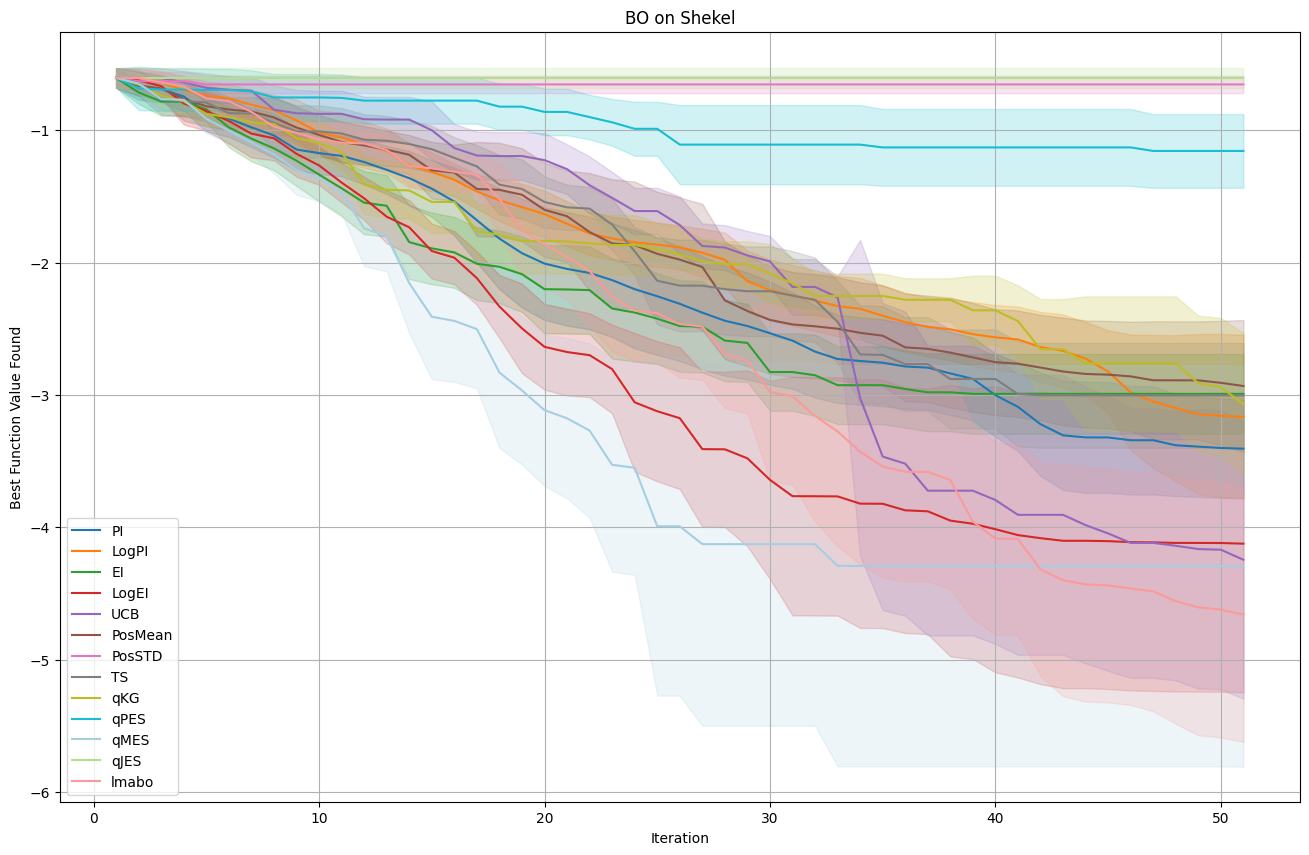

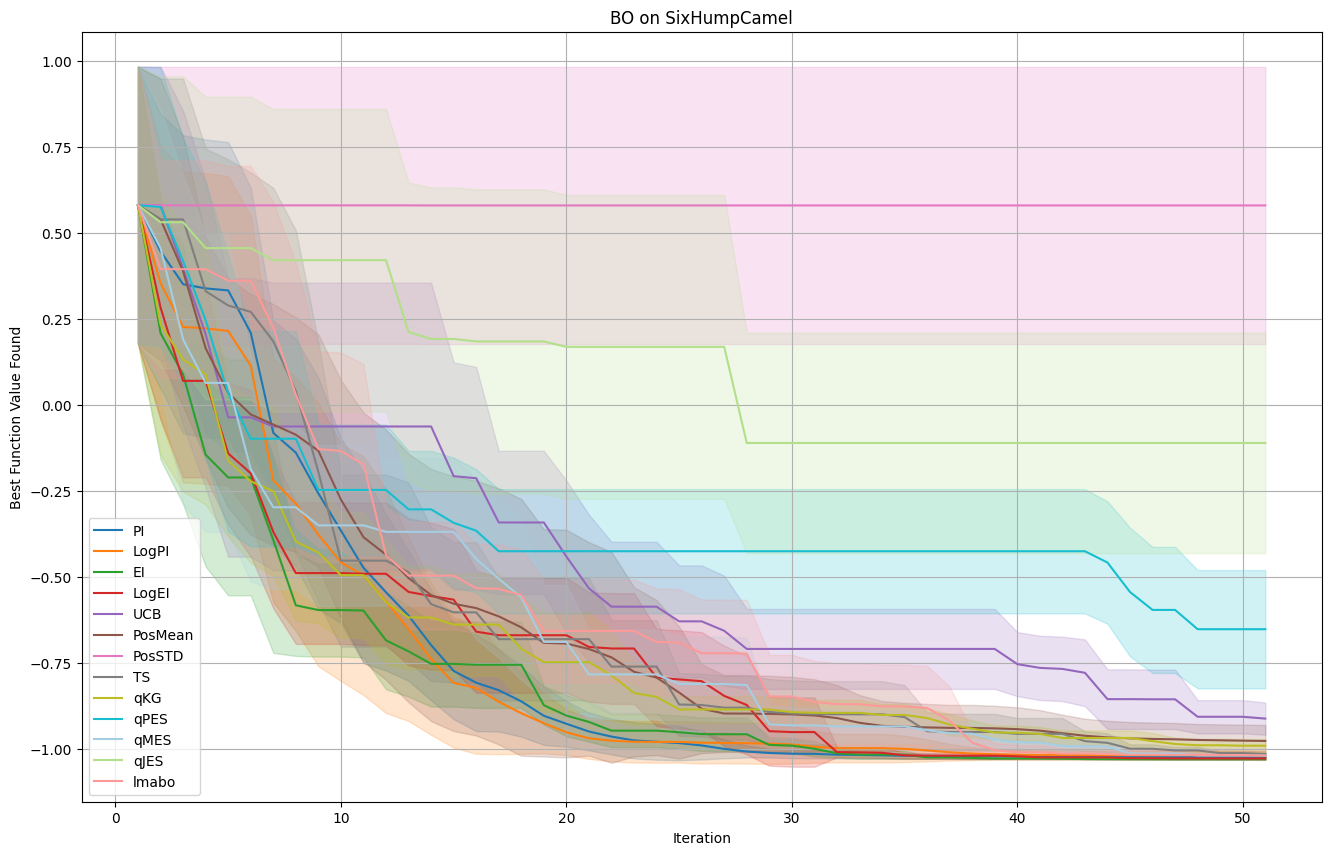

In [3]:
for problem in completed_problems:
    plot_results(problem)

In [61]:
for problem in completed_problems:
    print(problem, get_ranking(problem))

Branin {'EI': 1, 'LogEI': 2, 'TS': 3, 'lmabo': 4, 'qMES': 5, 'qKG': 6, 'UCB': 7, 'PI': 8, 'LogPI': 9, 'PosMean': 10, 'qPES': 11, 'qJES': 12, 'PosSTD': 13}
Easom {'LogPI': 1, 'lmabo': 2, 'PosMean': 3, 'UCB': 4, 'PI': 5, 'qJES': 6, 'EI': 7, 'LogEI': 8, 'qMES': 9, 'qPES': 10, 'PosSTD': 11, 'qKG': 12, 'TS': 13}
EggHolder {'lmabo': 1, 'UCB': 2, 'EI': 3, 'PI': 4, 'TS': 5, 'LogEI': 6, 'qMES': 7, 'qPES': 8, 'qKG': 9, 'PosMean': 10, 'LogPI': 11, 'qJES': 12, 'PosSTD': 13}
Griewank {'LogEI': 1, 'PosMean': 2, 'LogPI': 3, 'lmabo': 4, 'EI': 5, 'PI': 6, 'qKG': 7, 'UCB': 8, 'TS': 9, 'qMES': 10, 'PosSTD': 11, 'qPES': 12, 'qJES': 13}
Michalewicz {'PosMean': 1, 'LogPI': 2, 'PI': 3, 'EI': 4, 'LogEI': 5, 'lmabo': 6, 'qMES': 7, 'qKG': 8, 'PosSTD': 9, 'UCB': 10, 'TS': 11, 'qPES': 12, 'qJES': 13}
Shekel {'qMES': 1, 'LogEI': 2, 'lmabo': 3, 'EI': 4, 'PI': 5, 'UCB': 6, 'TS': 7, 'PosMean': 8, 'qKG': 9, 'LogPI': 10, 'qPES': 11, 'PosSTD': 12, 'qJES': 13}
SixHumpCamel {'EI': 1, 'LogPI': 2, 'PI': 3, 'lmabo': 4, 'LogE

In [60]:
get_problem_cum_reg("Michalewicz", "lmabo")

Run 0: 368.1195145026096
Run 1: 274.9753619494861
Run 2: 313.0518466636548
Run 3: 337.9267122014036
Run 4: 331.7406713385528
Run 5: 306.40276286202015
Run 6: 355.96036423925693
Run 7: 306.9404646916358
Run 8: 304.4271292855952
Run 9: 335.705818550366
323.52506462845815


In [58]:
get_problem_cum_reg("Michalewicz", "PosMean")

Run 0: 309.02323644596197
Run 1: 320.8750212655417
Run 2: 288.4147972254846
Run 3: 311.42622406329656
Run 4: 278.5006930305891
Run 5: 283.47242651268084
Run 6: 313.95489585413594
Run 7: 258.9380216474166
Run 8: 276.2649407390452
Run 9: 313.06525157253884
295.39355083566915


In [ ]:
run_problem_lmabo("Michalewicz")

cuda cuda:0
RUN 0
Run LMABO
Starting Gemini chat session with initial context...
Gemini's initial acknowledgement: Understood. I will provide only the abbreviation and justification.
Iter 0| 
Current optimization state:
- N: 21 
- Remaining iterations: 50
- D: 10
- f_min: -2.043
- Shortest distance: 1.01261853854514
- Lengthscales: Range [0.197, 2146.307], Mean 790.445 (Std Dev 743.763)
- Outputscale: 1.1985314205878788

LLM suggested AF: qMES justified by: [' Many iterations remaining in high-dimensional space with a complex, heterogeneous landscape (large lengthscale range). qMES is well-suited for efficient global optimization by actively reducing uncertainty about the true optimum.']
Current best value: -2.0431912010490425
Iter 1| 
Current optimization state:
- N: 22 
- Remaining iterations: 49
- D: 10
- f_min: -2.043
- Shortest distance: 0.9373717497247871
- Lengthscales: Range [0.197, 2146.307], Mean 790.445 (Std Dev 743.763)
- Outputscale: 1.1985314205878788

LLM suggested AF: T

LLM suggested AF: LogEI justified by: [" f_min is unchanged, and lengthscales are small and variable, indicating a challenging and potentially localized search. LogEI is well-suited for such scenarios as it's less sensitive to the specific scale of improvement and focuses on finding *any* improvement, which can be critical when progress is slow."]
Current best value: -2.7754323402210606
Iter 14| 
Current optimization state:
- N: 35 
- Remaining iterations: 36
- D: 10
- f_min: -2.775
- Shortest distance: 0.7602538303668999
- Lengthscales: Range [0.062, 403.600], Mean 166.595 (Std Dev 157.091)
- Outputscale: 0.8159767598629047

LLM suggested AF: TS justified by: [' f_min remains unchanged, and lengthscales are still quite variable, suggesting continued uncertainty. With many iterations left, Thompson Sampling can effectively explore new regions and balance the risk of getting stuck in a local minimum with the potential for new discoveries.']
Current best value: -2.7754323402210606
Iter 1

Current best value: -2.893127700348283
Iter 27| 
Current optimization state:
- N: 48 
- Remaining iterations: 23
- D: 10
- f_min: -2.893
- Shortest distance: 0.464727745970947
- Lengthscales: Range [0.060, 57.223], Mean 17.934 (Std Dev 23.302)
- Outputscale: 0.8463719666182438

LLM suggested AF: LogEI justified by: [' f_min is unchanged, and lengthscales have become very small and less variable, indicating a highly localized and potentially difficult search area. LogEI is suitable for focusing on any improvement, even if small, to refine the search in this constrained region.']
Current best value: -2.893127700348283
Iter 28| 
Current optimization state:
- N: 49 
- Remaining iterations: 22
- D: 10
- f_min: -2.893
- Shortest distance: 0.34608903875961544
- Lengthscales: Range [0.046, 167.274], Mean 52.907 (Std Dev 62.901)
- Outputscale: 0.8167996678764895

LLM suggested AF: TS justified by: [' f_min is unchanged and lengthscales are small but still somewhat variable. With a moderate numb